In [1]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.interpolate import UnivariateSpline
from scipy.optimize import curve_fit
import surfinBH
import lal
lal.swig_redirect_standard_output_error(False)


/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


True

Evaluating the entropy evolution from a simulated BBH using precession, fitting the behaviour using a second degree polynomial and pinpointing it's maximum, comparing it to the surrogate prediction

In [2]:
file_path = '/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q=0.40_chi1=0.20_chi2=0.20_th1=45_th2=45_dphi=90.csv'

In [3]:
# Read the initial setup (mass ratio and spins) from the header, then load the evolution data.
# Calculate the total mass by including the 0PN binding energy, and find the total angular momentum by combining the 0PN orbital momentum and spin vectors.

with open(file_path, 'r') as f:
    f.readline() 
    header_line = f.readline() 

q_prec = float(re.search(r'q=([\d.]+)', header_line).group(1))
chi1 = float(re.search(r'chi1=([\d.]+)', header_line).group(1))
chi2 = float(re.search(r'chi2=([\d.]+)', header_line).group(1))
theta1_0_deg = float(re.search(r'theta1_0_deg=([\d.]+)', header_line).group(1))
theta2_0_deg = float(re.search(r'theta2_0_deg=([\d.]+)', header_line).group(1))
deltaphi_0_deg = float(re.search(r'deltaphi_0_deg=([\d.]+)', header_line).group(1))
theta1_0_rad = np.radians(theta1_0_deg)
theta2_0_rad = np.radians(theta2_0_deg)
phi1_0_rad = 0
phi2_0_rad = np.radians(deltaphi_0_deg)

df = pd.read_csv(file_path, comment='#')
a = df['separation_M']
th1 = df['theta1_rad']
th2 = df['theta2_rad']
dphi = df['deltaphi_rad']

q = 1.0 / q_prec

m1 = q / (1 + q)
m2 = 1 / (1 + q)
eta = m1 * m2 

E_binding = (m1 * m2) / (2 * a)
M_tot = m1 + m2 - np.abs(E_binding)

 
S1 = chi1 * m1**2
S2 = chi2 * m2**2

L_0PN = eta * np.sqrt(a)

L_dot_S1 = L_0PN * S1 * np.cos(th1)
L_dot_S2 = L_0PN * S2 * np.cos(th2)
S1_dot_S2 = S1 * S2 * (np.sin(th1) * np.sin(th2) * np.cos(dphi) + 
                       np.cos(th1) * np.cos(th2))

J_tot = np.sqrt(L_0PN**2 + S1**2 + S2**2 + 2*L_dot_S1 + 2*L_dot_S2 + 2*S1_dot_S2)

In [4]:
# surrogate prediction
fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')


S1 = chi1 * m1**2
S2 = chi2 * m2**2

S1_x = S1 * np.sin(theta1_0_rad) * np.cos (phi1_0_rad)
S1_y = S1 * np.sin(theta1_0_rad) * np.sin(phi1_0_rad)
S1_z = S1 * np.cos(theta1_0_rad)

S2_x = S2 * np.sin(theta2_0_rad) * np.cos (phi2_0_rad)
S2_y = S2 * np.sin(theta2_0_rad) * np.sin(phi2_0_rad)
S2_z = S2 * np.cos(theta2_0_rad)

chiA = [S1_x, S1_y, S1_z]
chiB = [S2_x, S2_y, S2_z]

mf_surr, chif_surr, vf_surr, mf_err_surr, chif_err_surr, vf_err_surr = fit.all(q, chiA, chiB)

J_surr = np.sqrt ((chif_surr[0]**2) + (chif_surr[1]**2) + (chif_surr[2]**2))

Loaded NRSur7dq4EmriRemnant fit.


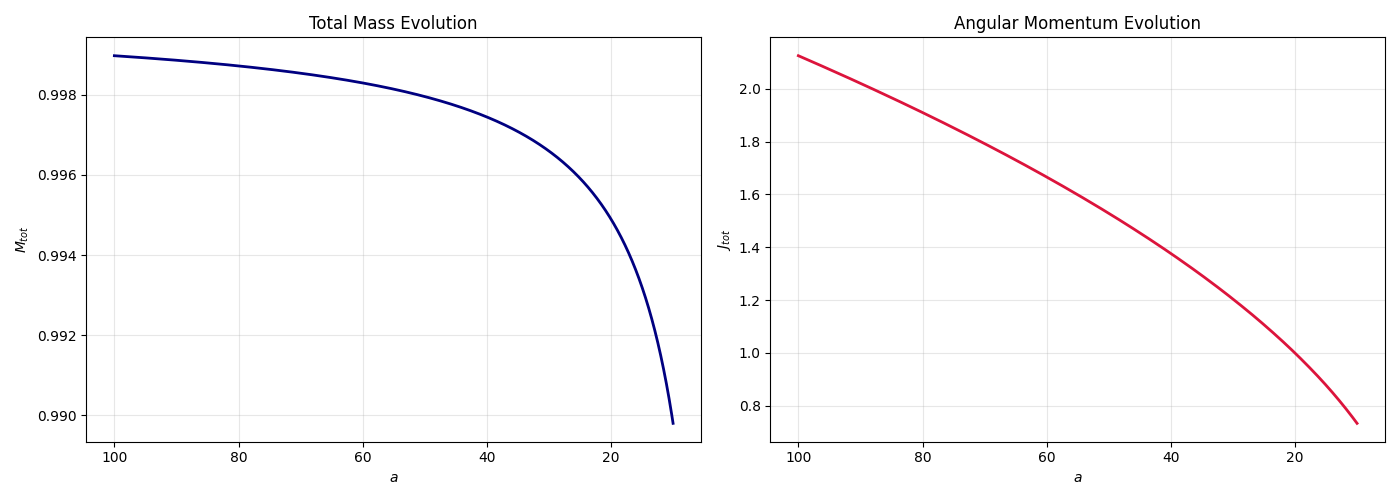

In [5]:
# plot of the Total Mass and Angular Momentum evolution

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Total Mass
ax[0].plot(a, M_tot, color='navy', lw=2)
ax[0].set_xlabel('$a$')
ax[0].set_ylabel('$M_{tot}$')
ax[0].set_title('Total Mass Evolution')
ax[0].grid(True, alpha=0.3)
ax[0].invert_xaxis() 

# Total Angular Momentum
ax[1].plot(a, J_tot, color='crimson', lw=2)
ax[1].set_xlabel('$a$')
ax[1].set_ylabel(r'$J_{tot}$')
ax[1].set_title('Angular Momentum Evolution')
ax[1].grid(True, alpha=0.3)
ax[1].invert_xaxis()

plt.tight_layout()
plt.show()

In [6]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)

    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

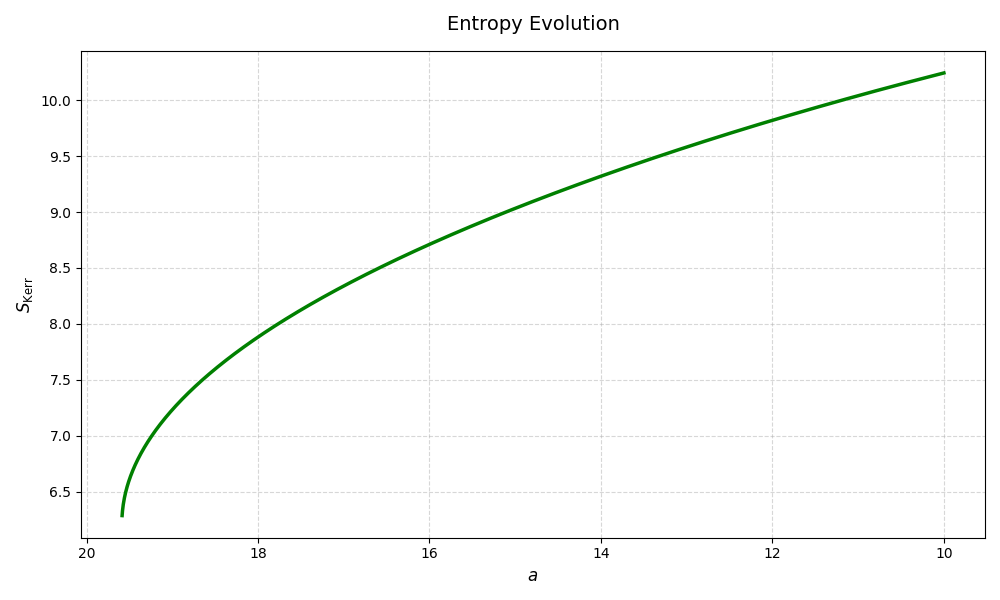

In [7]:
# plot of the Entropy evolution

ENT = entropy (M_tot, J_tot)
ENT_surr = entropy (mf_surr, J_surr)

valid_mask = ~np.isnan(ENT)

a_valid = np.array(a)[valid_mask]
ENT_valid = np.array(ENT)[valid_mask]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(a_valid, ENT_valid, color='green', lw=2.5)

ax.set_xlabel('$a$', fontsize=12)
ax.set_ylabel(r'$S_{\mathrm{Kerr}}$', fontsize=12)
ax.set_title('Entropy Evolution', fontsize=14, pad=15)
ax.invert_xaxis()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [8]:
# Clean up the data, sort it, and use a 2nd-degree polynomial to fit the mass and angular momentum based on the physical velocity parameter (1/sqrt(a)).
# Extrapolate those fits toward the merger to calculate the theoretical entropy, and pinpoint its maximum.

valid_mask = ~np.isnan(ENT)

valid_mask = ~np.isnan(ENT)
a_valid = np.array(a)[valid_mask]
M_tot_valid = np.array(M_tot)[valid_mask]
J_tot_valid = np.array(J_tot)[valid_mask]

sort_idx = np.argsort(a_valid)
a_fit = a_valid[sort_idx]
M_fit = M_tot_valid[sort_idx]
J_fit = J_tot_valid[sort_idx]


x_fit = 1.0 / np.sqrt(a_fit)
degree = 4


poly_M = np.poly1d(np.polyfit(x_fit, M_fit, degree))
poly_J = np.poly1d(np.polyfit(x_fit, J_fit, degree))


a_extrap = np.linspace(min(a_fit), 3.0, 1000)
x_extrap = 1.0 / np.sqrt(a_extrap)

M_extrap = poly_M(x_extrap)
J_extrap = poly_J(x_extrap)


ENT_extrap = entropy(M_extrap, J_extrap)


idx_max = np.nanargmax(ENT_extrap)
a_max_entropy = a_extrap[idx_max]
S_max_entropy = ENT_extrap[idx_max]

print(f"Maximum found at a = {a_max_entropy:.3f}")
print('0PN max entropy = ', S_max_entropy)
print('Predicted entropy = ', ENT_surr)
print('Delta S = ', np.abs(S_max_entropy - ENT_surr))

Maximum found at a = 6.532
0PN max entropy =  10.693503609548529
Predicted entropy =  10.282793166495255
Delta S =  0.410710443053274


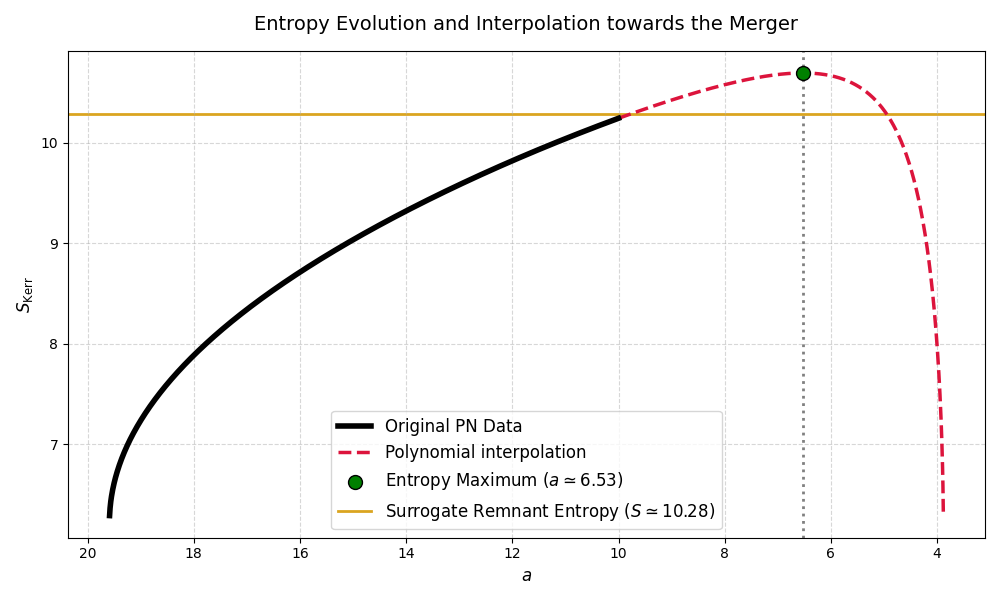

In [9]:
# plot of the predited entropy evolution after a = 10M

fig, ax = plt.subplots(figsize=(10, 6))
ENT_valid_sorted = np.array(ENT)[valid_mask][sort_idx]
ax.plot(a_fit, ENT_valid_sorted, color='black', lw=4, zorder=3,
        label='Original PN Data')

ax.plot(a_extrap, ENT_extrap, color='crimson', lw=2.5, linestyle='--', zorder=2,
        label='Polynomial interpolation')

ax.scatter([a_max_entropy], [S_max_entropy], color='green', edgecolor='black', s=100, zorder=4,
           label=f'Entropy Maximum ($a \\simeq {a_max_entropy:.2f}$)')
ax.axvline(a_max_entropy, color='gray', linestyle=':', lw=2, zorder=1)

ax.axhline(ENT_surr, color='goldenrod', linestyle='-', lw=2, zorder=1, 
           label=f'Surrogate Remnant Entropy ($S \\simeq {ENT_surr:.2f}$)')

ax.set_xlabel('$a$', fontsize=12)
ax.set_ylabel(r'$S_{\mathrm{Kerr}}$', fontsize=12)
ax.set_title('Entropy Evolution and Interpolation towards the Merger', fontsize=14, pad=15)
ax.invert_xaxis()
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='best')
plt.tight_layout()
plt.show()

Analisyng the alligned-spin scenario, evaluating the entropy error using 0PN approssimation at different spin and q configurations

In [10]:
# function to calculate the maximum entropy at 0PN

def get_max_0PN(q, chi1_z, chi2_z):
    
    m1 = q / (1 + q)
    m2 = 1 / (1 + q)
    eta = m1 * m2
    
    r_vals = np.linspace(50.0, 2.0, 1000)
    S_inst = np.zeros_like(r_vals)
    
    for i, r in enumerate(r_vals):
        E_bind = - (eta) / (2 * r)
        M_tot = 1.0 + E_bind
        L_orb = eta * np.sqrt(r)
        J_tot = L_orb + (m1**2)*chi1_z + (m2**2)*chi2_z
        S_inst[i] = entropy(M_tot, J_tot)
        
    valid = S_inst[~np.isnan(S_inst)]
    return np.max(valid) if len(valid) > 0 else np.nan


In [11]:
# evaluation of the error in entropy estimation, using a 0PN approximation against the surragate prediction
# Mass ratio is fixed while different spin configurations are analysed 

q_fix = 2.5

n_points = 25
chi_vals = np.linspace(-0.9, 0.9, n_points)

CHI1, CHI2 = np.meshgrid(chi_vals, chi_vals)
DELTA_S = np.zeros_like(CHI1)

print(f"Evaluating {n_points} spin configurations at q = {q_fix}")

for i in range(n_points):
    for j in range(n_points):
        c1 = CHI1[i, j]
        c2 = CHI2[i, j]
        
        mf, chif_vec, *_ = fit.all(q_fix, [0,0,c1], [0,0,c2])
        Jf = np.linalg.norm(chif_vec) * (mf**2)
        S_surr = entropy(mf, Jf)

        S_0pn = get_max_0PN(q_fix, c1, c2)

        DELTA_S[i, j] = np.abs(S_0pn - S_surr)

Evaluating 25 spin configurations at q = 2.5


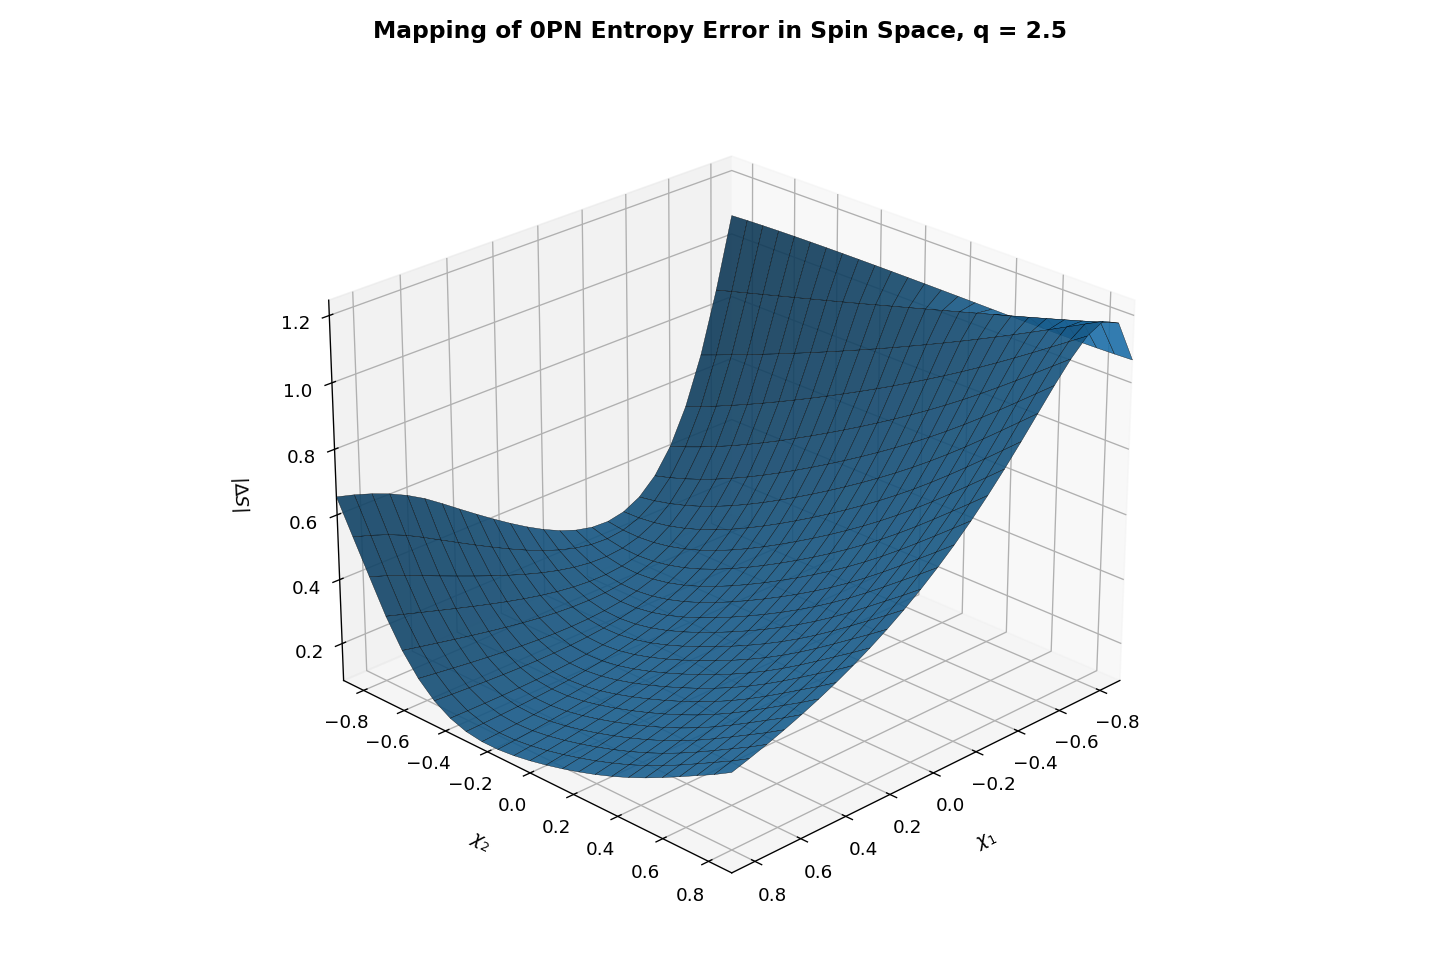

In [25]:
# 3D plot to visualize the impact of different spin configurations on the entropy estimation

plt.rcParams.update({'font.size': 11})
fig = plt.figure(figsize=(12, 8), dpi=120)
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(CHI1, CHI2, DELTA_S,  
                       edgecolor='black', linewidth=0.2, alpha=0.9, antialiased=True)
ax.set_xlabel(r' $\chi_1$', fontweight='bold', labelpad=12)
ax.set_ylabel(r'$\chi_2$', fontweight='bold', labelpad=12)
ax.set_zlabel(r'$|\Delta S|$', fontweight='bold', labelpad=12)
ax.set_title(f"Mapping of 0PN Entropy Error in Spin Space, q = {q_fix}", 
             fontweight='bold', pad=20, fontsize=14)
ax.set_xlim(-0.9, 0.9)
ax.set_ylim(-0.9, 0.9)
ax.view_init(elev=25, azim=45)
plt.tight_layout()
plt.show()

In [16]:
# evaluation of the error in entropy estimation, using a 0PN approximation against the surragate prediction
# different mass ratios are analysed
# scanning a 2D grid across mass ratio (q) and spin difference (Delta_chi).
# evaluating an anti-symmetric spin setup (chi_1 = -chi_2) 

n_points = 25 
q_vals = np.linspace(1.0, 10.0, n_points)

delta_chi_vals = np.linspace(-1.8, 1.8, n_points) 

Q, D_CHI = np.meshgrid(q_vals, delta_chi_vals)
DELTA_S = np.zeros_like(Q)

print(f"Evaluating {n_points} configurations")


for i in range(n_points):
    for j in range(n_points):
        q_curr = Q[i, j]
        d_chi = D_CHI[i, j]
        
        c1 = d_chi / 2.0
        c2 = -d_chi / 2.0
        
        mf, chif_vec, *_ = fit.all(q_curr, [0,0,c1], [0,0,c2])
        Jf = np.linalg.norm(chif_vec) * (mf**2)
        S_surr = entropy(mf, Jf)

        S_0pn = get_max_0PN(q_curr, c1, c2)
        
        DELTA_S[i, j] = np.abs(S_0pn - S_surr)

Evaluating 25 configurations


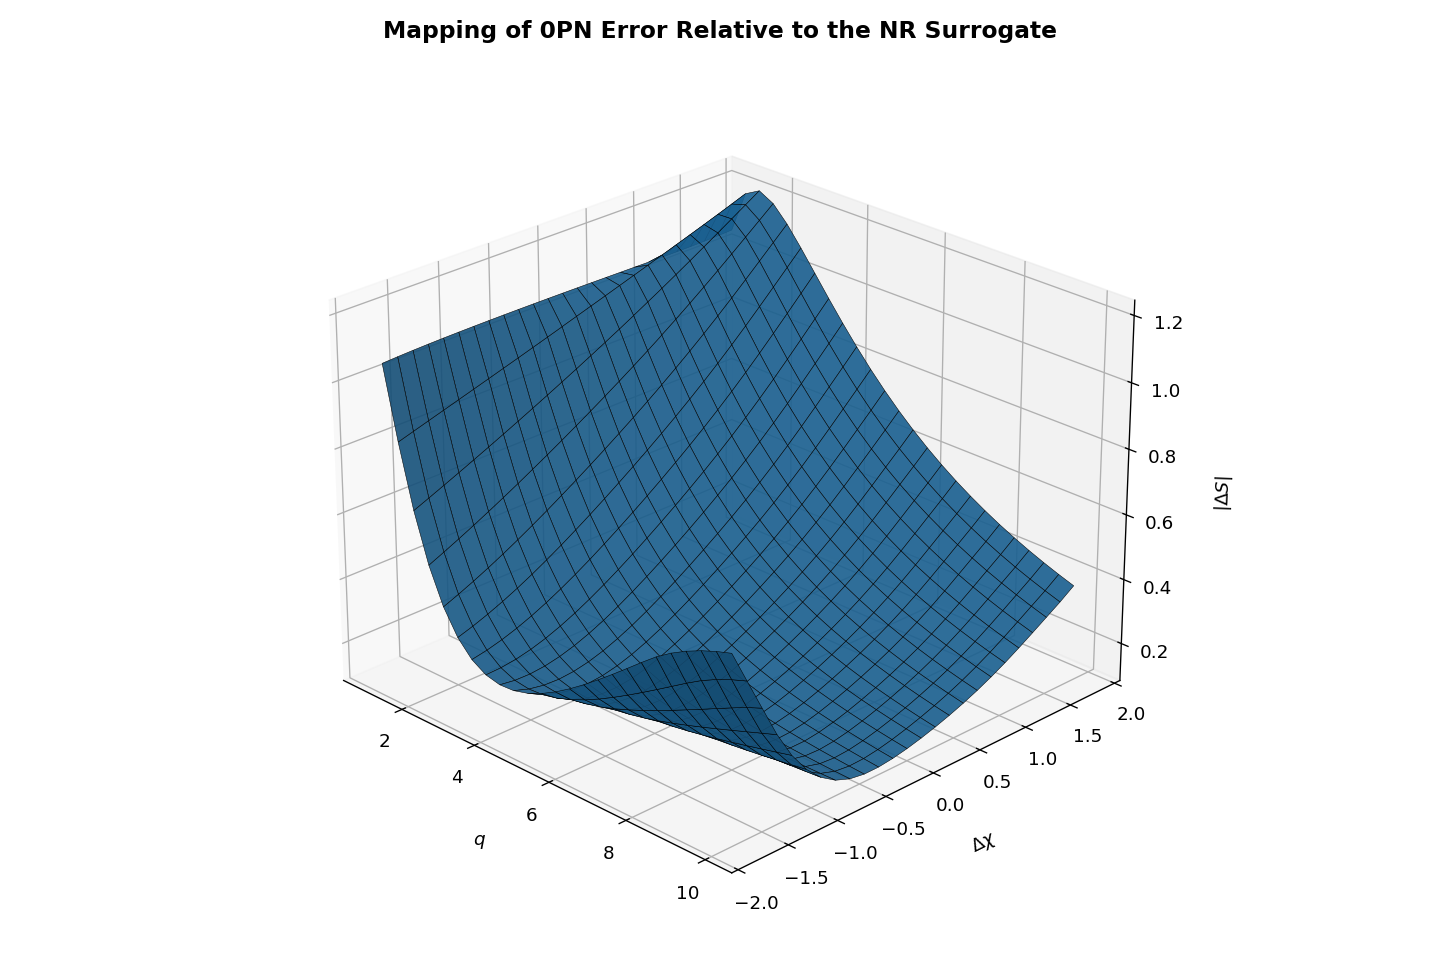

In [26]:
plt.rcParams.update({'font.size': 11})
fig = plt.figure(figsize=(12, 8), dpi=120)
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(Q, D_CHI, DELTA_S, 
                       edgecolor='black', linewidth=0.3, alpha=0.9, antialiased=True)
ax.set_xlabel('$q$', fontweight='bold', labelpad=12)
ax.set_ylabel(r'$\Delta\chi$', fontweight='bold', labelpad=12)
ax.set_zlabel(r'$|\Delta S|$', fontweight='bold', labelpad=12)
ax.set_title("Mapping of 0PN Error Relative to the NR Surrogate", 
             fontweight='bold', pad=20, fontsize=14)
ax.view_init(elev=25, azim=-45)
plt.tight_layout()
plt.show()